In [ ]:
import timeit
import seaborn as sns
import matplotlib.pyplot as plt
import random
import pandas as pd

In [ ]:
# C : capacidad total de la mochila.
# p : Peso por objeto i.
# v : Valor por objeto i.
# n : cantidad de objetos.

# memoria para almacenar soluciones {C,n} en un diccionario.

memoria = {}

def Mochila(p, v, n, C):

    # se define el caso base (cuando no quedan objetos ni capacidad)

    if n == 0 or C == 0:
        return 0

    # si el ultimo objeto considerado excede la capacidad de la mochila...
    # llama recursivamente la función sin ese objeto.

    if (p[n - 1] > C):
        return Mochila(p, v, n - 1, C)

    # Revisar si la solución del subproblema ya se encuentra memoizado.

    if (C, n) in memoria:
        return memoria[(C, n)]

    # si se toma el valor actual, suma su valor, resta la capacidad total y llama recursivamente la función sin tomar en cuenta ese objeto.

    valor_tomado = v[n - 1] + Mochila( p, v, n - 1, C - p[n-1])

    # si no se toma el objeto actual, llama a la función recursiva sin el objeto actual.

    valor_notomado = Mochila(p, v, n - 1, C)

    # para ambos casos, toma el maximo de esos valores.

    valor_max = max(valor_tomado, valor_notomado)

    # guarda la solución optima en la memoria.

    memoria[(C, n)] = valor_max

    # retorna el valor máximo.

    return valor_max

In [ ]:
def Mochila_Bt(p, v, n, C, i=0, p_act=0, v_act=0):

    # Caso base, si recorrimos todos los objetos.

    if i == n:
        return v_act

    # si no toma el objeto actual, avanza al siguiente.
    max_valor = Mochila_Bt(p, v, n, C, i + 1, p_act, v_act)


    # si toma el objeto actual, su peso + el peso acumulado no debe exceder la capacidad total de la mochila.
    # de cumplirse esa condición, avanza al siguiente objeto, acumulando peso y valor.

    if p_act + p[i] <= C:
        max_valor = max(
            max_valor,
            Mochila_Bt(
                p, v, n, C,
                i + 1,
                p_act + p[i],
                v_act + v[i]
            )
        )

    # retorna el maximo valor encontrado.

    return max_valor

In [ ]:
import timeit

instancias = [
    {
        "ejemplo": 1,
        "n": 9,
        "p": [6, 4, 8, 4, 3, 5, 5, 1, 1],
        "v": [6, 12, 18, 19, 4, 3, 17, 3, 15],
        "C": 25
    },
    {
        "ejemplo": 2,
        "n": 9,
        "p": [8, 2, 3, 5, 7, 4, 4, 1, 3],
        "v": [4, 17, 14, 12, 12, 9, 10, 20, 7],
        "C": 26
    },
    {
        "ejemplo": 3,
        "n": 7,
        "p": [6, 8, 9, 9, 8, 6, 4],
        "v": [18, 6, 17, 12, 13, 10, 14],
        "C": 13
    },
    {
        "ejemplo": 4,
        "n": 10,
        "p": [7, 1, 8, 5, 8, 5, 3, 3, 1, 9],
        "v": [17, 18, 14, 12, 2, 11, 1, 14, 1, 19],
        "C": 12
    },
    {
        "ejemplo": 5,
        "n": 9,
        "p": [9, 2, 4, 4, 10, 7, 10, 3, 5],
        "v": [4, 8, 5, 19, 12, 20, 1, 4, 9],
        "C": 30
    },
    {
        "ejemplo": 6,
        "n": 8,
        "p": [10, 10, 1, 4, 6, 2, 2, 7],
        "v": [16, 17, 7, 3, 12, 17, 8, 2],
        "C": 27
    },
    {
        "ejemplo": 7,
        "n": 7,
        "p": [1, 3, 6, 4, 7, 9, 6],
        "v": [16, 2, 19, 6, 17, 8, 20],
        "C": 28
    },
    {
        "ejemplo": 8,
        "n": 6,
        "p": [7, 8, 2, 5, 6, 10],
        "v": [18, 12, 13, 19, 15, 11],
        "C": 26
    },
    {
        "ejemplo": 9,
        "n": 5,
        "p": [4, 4, 4, 3, 1],
        "v": [17, 4, 9, 1, 9],
        "C": 11
    },
    {
        "ejemplo": 10,
        "n": 9,
        "p": [9, 1, 7, 3, 7, 5, 1, 5, 4],
        "v": [13, 5, 17, 6, 12, 12, 20, 9, 20],
        "C": 26
    }
]

resultados = {
    "DP": [],
    "Backtracking": []
}

for inst in instancias:
    p = inst["p"]
    v = inst["v"]
    C = inst["C"]
    n = inst["n"]
    ejemplo = inst["ejemplo"]

    def ejecutar_dp():
        return Mochila(p, v, n, C)

    tiempo_dp = timeit.timeit(ejecutar_dp, number=1)
    resultado_dp = ejecutar_dp()

    resultados["DP"].append({
        "ejemplo": ejemplo,
        "n": n,
        "C": C,
        "tiempo": tiempo_dp,
        "resultado": resultado_dp
    })

    tiempo_bt = timeit.timeit(lambda: Mochila_Bt(p, v, n, C), number=1)
    resultado_bt = Mochila_Bt(p, v, n, C)

    resultados["Backtracking"].append({
        "ejemplo": ejemplo,
        "n": n,
        "C": C,
        "tiempo": tiempo_bt,
        "resultado": resultado_bt
    })

print("INSTANCIAS GENERADAS")

for inst in instancias:
    print(f"\nEjemplo {inst['ejemplo']}")
    print(f"n: {inst['n']}")
    print(f"Pesos: {inst['p']}")
    print(f"Valores: {inst['v']}")
    print(f"Capacidad: {inst['C']}")

for metodo, lista in resultados.items():
    print(f"\n=== {metodo} ===")
    for r in lista:
        print(
            f"Ejemplo {r['ejemplo']} | "
            f"n={r['n']} | "
            f"C={r['C']} | "
            f"Tiempo: {r['tiempo']:.6f} s | "
            f"Resultado: {r['resultado']}"
        )

INSTANCIAS GENERADAS

Ejemplo 1
n: 9
Pesos: [6, 4, 8, 4, 3, 5, 5, 1, 1]
Valores: [6, 12, 18, 19, 4, 3, 17, 3, 15]
Capacidad: 25

Ejemplo 2
n: 9
Pesos: [8, 2, 3, 5, 7, 4, 4, 1, 3]
Valores: [4, 17, 14, 12, 12, 9, 10, 20, 7]
Capacidad: 26

Ejemplo 3
n: 7
Pesos: [6, 8, 9, 9, 8, 6, 4]
Valores: [18, 6, 17, 12, 13, 10, 14]
Capacidad: 13

Ejemplo 4
n: 10
Pesos: [7, 1, 8, 5, 8, 5, 3, 3, 1, 9]
Valores: [17, 18, 14, 12, 2, 11, 1, 14, 1, 19]
Capacidad: 12

Ejemplo 5
n: 9
Pesos: [9, 2, 4, 4, 10, 7, 10, 3, 5]
Valores: [4, 8, 5, 19, 12, 20, 1, 4, 9]
Capacidad: 30

Ejemplo 6
n: 8
Pesos: [10, 10, 1, 4, 6, 2, 2, 7]
Valores: [16, 17, 7, 3, 12, 17, 8, 2]
Capacidad: 27

Ejemplo 7
n: 7
Pesos: [1, 3, 6, 4, 7, 9, 6]
Valores: [16, 2, 19, 6, 17, 8, 20]
Capacidad: 28

Ejemplo 8
n: 6
Pesos: [7, 8, 2, 5, 6, 10]
Valores: [18, 12, 13, 19, 15, 11]
Capacidad: 26

Ejemplo 9
n: 5
Pesos: [4, 4, 4, 3, 1]
Valores: [17, 4, 9, 1, 9]
Capacidad: 11

Ejemplo 10
n: 9
Pesos: [9, 1, 7, 3, 7, 5, 1, 5, 4]
Valores: [13, 5, 17, 6, 12,

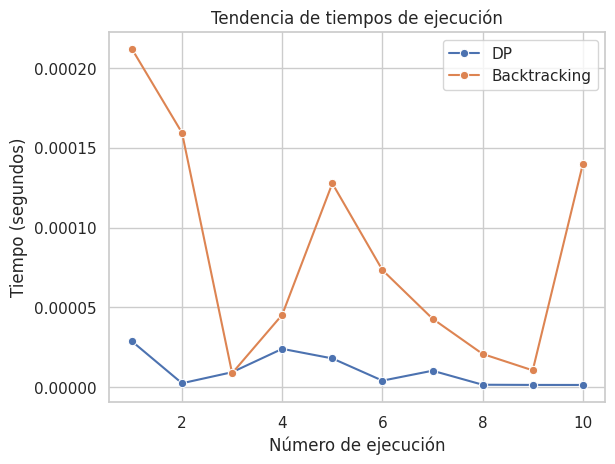

In [ ]:
ejecuciones = [r["ejemplo"] for r in resultados["DP"]]
tiempos_dp = [r["tiempo"] for r in resultados["DP"]]
tiempos_bt = [r["tiempo"] for r in resultados["Backtracking"]]

sns.set(style="whitegrid")

plt.figure()

# Línea DP
sns.lineplot(x=ejecuciones, y=tiempos_dp, marker="o", label="DP")

# Línea Backtracking
sns.lineplot(x=ejecuciones, y=tiempos_bt, marker="o", label="Backtracking")

plt.xlabel("Número de ejecución")
plt.ylabel("Tiempo (segundos)")
plt.title("Tendencia de tiempos de ejecución")

plt.legend()
plt.show()

plt.show()

In [ ]:
tiempos_dp = [r["tiempo"] for r in resultados["DP"]]
tiempos_bt = [r["tiempo"] for r in resultados["Backtracking"]]

promedio = sum(tiempos_dp) / len(tiempos_dp)
print(f"Tiempo promedio DP: {promedio:.6f} segundos")
promedio_bt = sum(tiempos_bt) / len(tiempos_bt)
print(f"Tiempo promedio Backtracking: {promedio_bt:.6f}")

Tiempo promedio DP: 0.000010 segundos
Tiempo promedio Backtracking: 0.000084


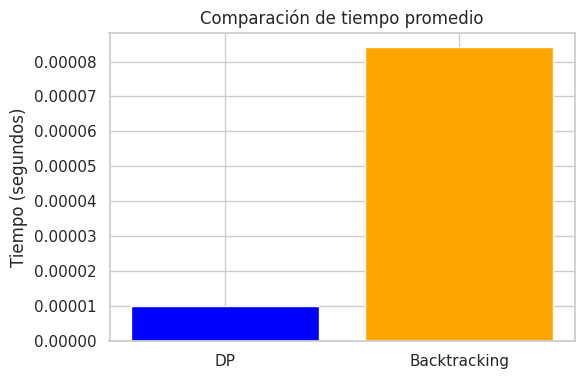

In [ ]:
metodos = ["DP", "Backtracking"]
tiempo = [promedio, promedio_bt]

plt.figure(figsize=(6, 4))
plt.bar(metodos, tiempo, color = ["blue", "orange"])

plt.title("Comparación de tiempo promedio")
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel("Tiempo (segundos)")

plt.show()

In [ ]:
data = []

for i in range(len(instancias)):

    inst = instancias[i]

    dp = resultados["DP"][i]
    bt = resultados["Backtracking"][i]

    data.append({
        "Ejemplo": inst["ejemplo"],
        "n": inst["n"],
        "Capacidad": inst["C"],

        "Tiempo_DP": dp["tiempo"],
        "Resultado_DP": dp["resultado"],

        "Tiempo_BT": bt["tiempo"],
        "Resultado_BT": bt["resultado"]
    })

df = pd.DataFrame(data)

print(df)

   Ejemplo   n  Capacidad  Tiempo_DP  Resultado_DP  Tiempo_BT  Resultado_BT
0        1   9         25   0.000029            72   0.000212            85
1        2   9         26   0.000002            89   0.000159            94
2        3   7         13   0.000009            36   0.000009            32
3        4  10         12   0.000024            37   0.000045            50
4        5   9         30   0.000018            74   0.000128            68
5        6   8         27   0.000004            61   0.000073            65
6        7   7         28   0.000010            67   0.000043            80
7        8   6         26   0.000001            53   0.000021            65
8        9   5         11   0.000001            28   0.000010            35
9       10   9         26   0.000001            89   0.000140            89


In [ ]:
ejecucion_c =[1,2,3,4,5,6,7,8,9,10]

tiempos_dp_c = [
    0.000096,
    0.000088,
    0.000007,
    0.000035,
    0.000094,
    0.000055,
    0.000054,
    0.000025,
    0.000010,
    0.000085
]

tiempos_bt_c = [
    0.000007,
    0.000008,
    0.000001,
    0.000003,
    0.000007,
    0.000004,
    0.000002,
    0.000001,
    0.000001,
    0.000007
]


promedio_c = sum(tiempos_dp_c) / len(tiempos_dp_c)
print(f"Tiempo promedio DP: {promedio_c:.6f} segundos")
promedio_bt_c = sum(tiempos_bt_c) / len(tiempos_bt_c)
print(f"Tiempo promedio Backtracking: {promedio_bt_c:.6f}")

Tiempo promedio DP: 0.000055 segundos
Tiempo promedio Backtracking: 0.000004


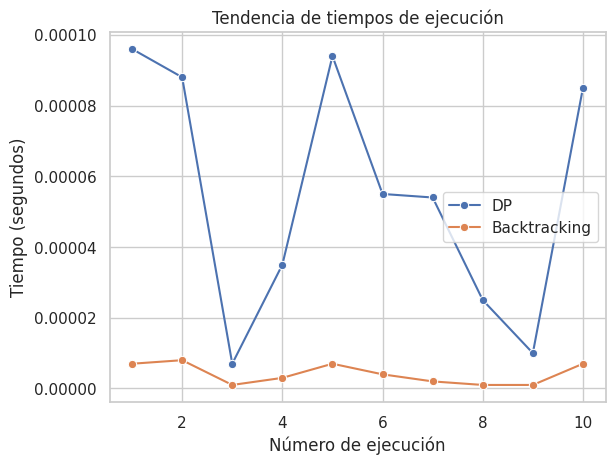

In [ ]:
sns.set(style="whitegrid")

plt.figure()

# Línea DP
sns.lineplot(x=ejecucion_c, y=tiempos_dp_c, marker="o", label="DP")

# Línea Backtracking
sns.lineplot(x=ejecucion_c, y=tiempos_bt_c, marker="o", label="Backtracking")

plt.xlabel("Número de ejecución")
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel("Tiempo (segundos)")
plt.title("Tendencia de tiempos de ejecución")

plt.legend()
plt.show()


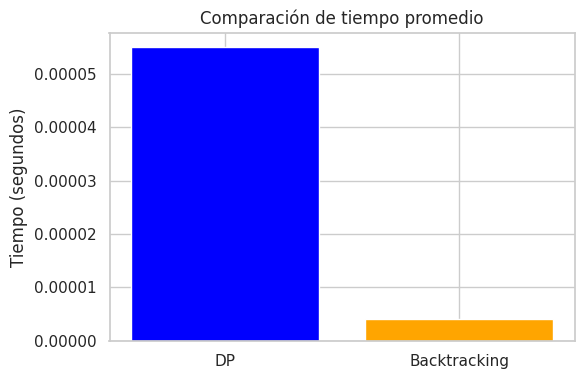

In [ ]:
metodos = ["DP", "Backtracking"]
tiempo = [promedio_c, promedio_bt_c]

plt.figure(figsize=(6, 4))
plt.bar(metodos, tiempo, color = ["blue", "orange"])

plt.title("Comparación de tiempo promedio")
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel("Tiempo (segundos)")

plt.show()

In [ ]:
ejecucion_j =[1,2,3,4,5,6,7,8,9,10]

tiempos_dp_j= [
    0.002815,
    0.000288,
    0.000022,
    0.000098,
    0.000176,
    0.000069,
    0.000061,
    0.000044,
    0.000012,
    0.000103
]

tiempos_bt_j = [
    0.000053,
    0.000042,
    0.000003,
    0.000010,
    0.000006,
    0.000003,
    0.000002,
    0.000002,
    0.000001,
    0.000006
]

promedio_j = sum(tiempos_dp_j) / len(tiempos_bt_j)
print(f"Tiempo promedio DP: {promedio_j:.6f} segundos")
promedio_bt_j= sum(tiempos_bt_j) / len(tiempos_bt_j)
print(f"Tiempo promedio Backtracking: {promedio_bt_c:.6f}")

Tiempo promedio DP: 0.000369 segundos
Tiempo promedio Backtracking: 0.000004


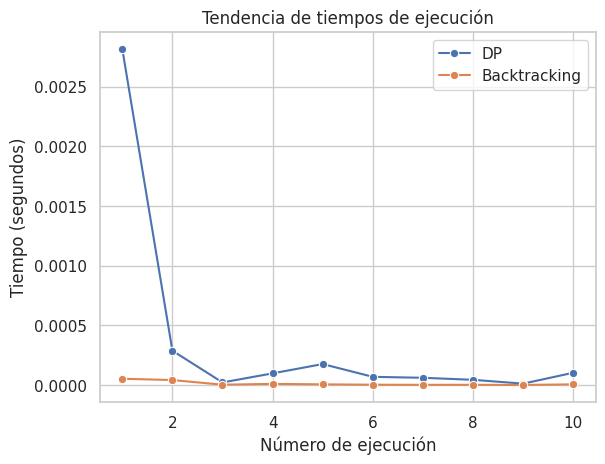

In [ ]:
sns.set(style="whitegrid")

plt.figure()

# Línea DP
sns.lineplot(x=ejecucion_c, y=tiempos_dp_j, marker="o", label="DP")

# Línea Backtracking
sns.lineplot(x=ejecucion_c, y=tiempos_bt_j, marker="o", label="Backtracking")

plt.xlabel("Número de ejecución")
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel("Tiempo (segundos)")
plt.title("Tendencia de tiempos de ejecución")

plt.legend()
plt.show()


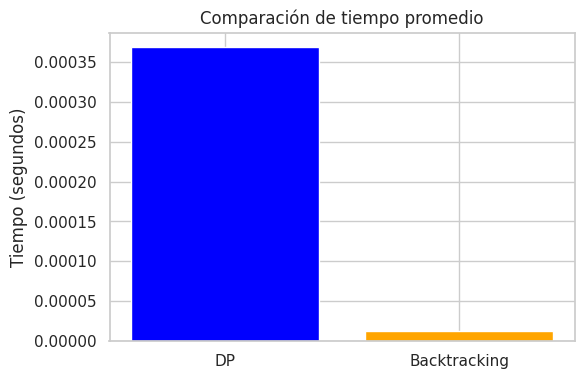

In [ ]:
metodos = ["DP", "Backtracking"]
tiempo = [promedio_j, promedio_bt_j]

plt.figure(figsize=(6, 4))
plt.bar(metodos, tiempo, color = ["blue", "orange"])

plt.title("Comparación de tiempo promedio")
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel("Tiempo (segundos)")

plt.show()

In [ ]:


instancias = [
    {"Ejemplo": 1, "n": 9, "Pesos": [6,4,8,4,3,5,5,1,1], "Valores": [6,12,18,19,4,3,17,3,15], "Capacidad": 25},
    {"Ejemplo": 2, "n": 9, "Pesos": [8,2,3,5,7,4,4,1,3], "Valores": [4,17,14,12,12,9,10,20,7], "Capacidad": 26},
    {"Ejemplo": 3, "n": 7, "Pesos": [6,8,9,9,8,6,4], "Valores": [18,6,17,12,13,10,14], "Capacidad": 13},
    {"Ejemplo": 4, "n": 10, "Pesos": [7,1,8,5,8,5,3,3,1,9], "Valores": [17,18,14,12,2,11,1,14,1,19], "Capacidad": 12},
    {"Ejemplo": 5, "n": 9, "Pesos": [9,2,4,4,10,7,10,3,5], "Valores": [4,8,5,19,12,20,1,4,9], "Capacidad": 30},
    {"Ejemplo": 6, "n": 8, "Pesos": [10,10,1,4,6,2,2,7], "Valores": [16,17,7,3,12,17,8,2], "Capacidad": 27},
    {"Ejemplo": 7, "n": 7, "Pesos": [1,3,6,4,7,9,6], "Valores": [16,2,19,6,17,8,20], "Capacidad": 28},
    {"Ejemplo": 8, "n": 6, "Pesos": [7,8,2,5,6,10], "Valores": [18,12,13,19,15,11], "Capacidad": 26},
    {"Ejemplo": 9, "n": 5, "Pesos": [4,4,4,3,1], "Valores": [17,4,9,1,9], "Capacidad": 11},
    {"Ejemplo": 10, "n": 9, "Pesos": [9,1,7,3,7,5,1,5,4], "Valores": [13,5,17,6,12,12,20,9,20], "Capacidad": 26}
]

df_instancias = pd.DataFrame(instancias)

print(df_instancias.to_string(index=False))

 Ejemplo  n                          Pesos                               Valores  Capacidad
       1  9    [6, 4, 8, 4, 3, 5, 5, 1, 1]      [6, 12, 18, 19, 4, 3, 17, 3, 15]         25
       2  9    [8, 2, 3, 5, 7, 4, 4, 1, 3]     [4, 17, 14, 12, 12, 9, 10, 20, 7]         26
       3  7          [6, 8, 9, 9, 8, 6, 4]           [18, 6, 17, 12, 13, 10, 14]         13
       4 10 [7, 1, 8, 5, 8, 5, 3, 3, 1, 9] [17, 18, 14, 12, 2, 11, 1, 14, 1, 19]         12
       5  9  [9, 2, 4, 4, 10, 7, 10, 3, 5]        [4, 8, 5, 19, 12, 20, 1, 4, 9]         30
       6  8     [10, 10, 1, 4, 6, 2, 2, 7]          [16, 17, 7, 3, 12, 17, 8, 2]         27
       7  7          [1, 3, 6, 4, 7, 9, 6]             [16, 2, 19, 6, 17, 8, 20]         28
       8  6            [7, 8, 2, 5, 6, 10]              [18, 12, 13, 19, 15, 11]         26
       9  5                [4, 4, 4, 3, 1]                      [17, 4, 9, 1, 9]         11
      10  9    [9, 1, 7, 3, 7, 5, 1, 5, 4]     [13, 5, 17, 6, 12, 12, 20, 9, 20]